In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [21]:
df = pd.read_csv("./diabetes.csv")

In [22]:
cols=list(df.columns)
print(cols)

['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi', 'pedigree', 'age', 'label']


In [23]:
lbl ="label"

In [24]:
from sklearn.linear_model import LogisticRegression
# create decision tree classifier object
clf = LogisticRegression(max_iter=1000, solver="lbfgs")

In [25]:
df.head()

,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
cols.remove(lbl)
feature_cols = cols
print (feature_cols)

['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi', 'pedigree', 'age']


In [27]:
X = df[feature_cols] # Features
y = df[lbl] # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state= 1)

In [28]:
#Train Classifer

model = clf.fit(X_train, y_train)
#predit the response for the dataset
y_pred = model.predict(X_test)

In [29]:
#Claculate accurracy
from sklearn import metrics

In [30]:
result = metrics.confusion_matrix(y_test, y_pred)
print ("Confusion Matrix:")
print (result)

Confusion Matrix:
[[132  14]
 [ 36  49]]


In [31]:
# [row, column]
TP = result [1,1]
TN = result [0,0]
FP = result [0,1]
FN = result [1,0]

In [32]:
print("Accuracy:\t",metrics.accuracy_score(y_test, y_pred))
print("Sensitivity:\t",metrics.recall_score(y_test, y_pred))
print("Specificity:\t",TN / (TN + FP))
print("Precision:\t",metrics.precision_score(y_test, y_pred))
print("Classification Eerror:", 1 - metrics.accuracy_score(y_test, y_pred))
print("False_Positive_Rate:",1 - TN / (TN + FP))

Accuracy:	 0.7835497835497836
Sensitivity:	 0.5764705882352941
Specificity:	 0.9041095890410958
Precision:	 0.7777777777777778
Classification Eerror: 0.21645021645021645
False_Positive_Rate: 0.09589041095890416


In [33]:
def ClsMdl(y_test, y_pred, TN, TP, FN, FP):
    """Display classification model metrics"""
    print("Classification Model Metrics:")
    print("=" * 50)
    print(f"True Negatives (TN):  {TN}")
    print(f"True Positives (TP):  {TP}")
    print(f"False Negatives (FN): {FN}")
    print(f"False Positives (FP): {FP}")
    print("=" * 50)
    print(f"Accuracy:   {metrics.accuracy_score(y_test, y_pred):.4f}")
    print(f"Sensitivity: {TP / (TP + FN):.4f}")
    print(f"Specificity: {TN / (TN + FP):.4f}")
    print(f"Precision:  {TP / (TP + FP):.4f}")
    print(f"F1-Score:   {2 * (TP / (TP + FP)) * (TP / (TP + FN)) / ((TP / (TP + FP)) + (TP / (TP + FN))):.4f}")

In [34]:
ClsMdl(y_test, y_pred, TN, TP, FN, FP)

Classification Model Metrics:
True Negatives (TN):  132
True Positives (TP):  49
False Negatives (FN): 36
False Positives (FP): 14
Accuracy:   0.7835
Sensitivity: 0.5765
Specificity: 0.9041
Precision:  0.7778
F1-Score:   0.6622


In [35]:
y = pd.DataFrame({'Original': y_test,'Predicted' : y_pred})
y.head()

,Original,Predicted
285,0,0
101,0,0
581,0,0
352,0,0
726,0,0


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

### ROC curve

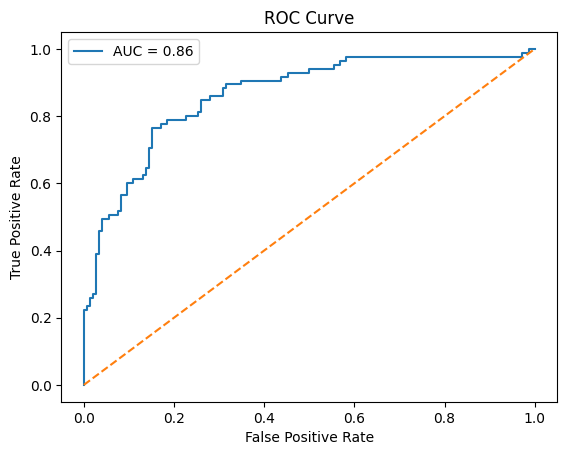

In [38]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Sigmoid Function

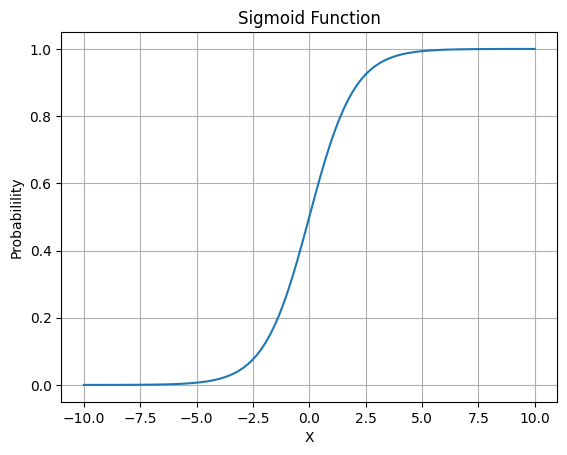

In [39]:
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-X))

plt.plot(X, y)
plt.title("Sigmoid Function")
plt.xlabel("X")
plt.ylabel("Probabilility")
plt.grid()
plt.show()